# 🎓 SafeDrive AI: RAG Multimodal & Edge AI (Notebook Final TFG)

**Objetivo:** Arquitectura definitiva del sistema RAG local para el asistente post-accidente. 
Implementa Clean Code, ingesta multimodal con control de cuota (Gemini API), chunking optimizado para textos jurídico-médicos, y visualizaciones semánticas.

## 🗺️ Flujo del Sistema
1. Instalación de dependencias
2. Importaciones centralizadas (Clean Code)
3. Configuración Global (Hiperparámetros)
4. Ingesta Multimodal Segura (Gemini Vision + Rate Limiting)
5. Chunking de Alta Densidad Semántica
6. Indexación en ChromaDB (Local)
7. Pipeline RAG Edge (Inferencia Local)
8. Pruebas de Estrés
9. Visualización 2D (PCA Local)
10. Exportación a TensorFlow Embedding Projector

## 🔧 Paso 1: Instalación de dependencias

In [1]:
!pip install langchain langchain-chroma langchain-ollama chromadb pypdfium2 google-genai pillow scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📦 Paso 2: Importaciones Centralizadas (Clean Code)
Agrupamos todas las librerías en la primera celda ejecutable para evitar errores de dependencias en el flujo.

In [2]:
# 1. Librerías del Sistema y Datos
import os
import csv
import time
from pathlib import Path
from tqdm import tqdm

# 2. Librerías de Procesamiento de Imágenes y PDFs
from PIL import Image
import pypdfium2 as pdfium

# 3. Librería del Modelo de Visión 
import base64
from io import BytesIO
from langchain_core.messages import HumanMessage
from langchain_core.prompts import PromptTemplate

# 4. Librerías de LangChain y Arquitectura RAG
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings, OllamaLLM, ChatOllama
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

# 5. Librerías para Análisis Matemático y Visualización (PCA)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("✅ Todas las librerías importadas correctamente. Entorno listo.")

C:\Users\LittleDragon\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Todas las librerías importadas correctamente. Entorno listo.


## ⚙️ Paso 3: Configuración Global (Hiperparámetros y Rutas)
Definición estricta de parámetros. Hemos ajustado el `CHUNK_SIZE` a 512 y el `CHUNK_OVERLAP` a 150 para maximizar la cohesión de los artículos legales y evitar fragmentación semántica.

In [3]:
# --- RUTAS DE DIRECTORIOS ---
DATA_DIR = "../data/" 
CHROMA_DIR = "../chroma_db/dgt_multimodal"
COLLECTION_NAME = "BOE_dgt_seguridad"

# --- CONFIGURACIÓN DE MODELOS ---
OLLAMA_BASE_URL = "http://localhost:11434"
EMBEDDING_MODEL = "nomic-embed-text"
LLM_MODEL = "qwen2.5:7b"
OLLAMA_VISION_MODEL = "qwen2.5vl"

# --- CONFIGURACIÓN RAG (Densidad Semántica) ---
CHUNK_SIZE = 512
CHUNK_OVERLAP = 150

print(f"✅ Configuración global cargada: Chunk={CHUNK_SIZE}, Overlap={CHUNK_OVERLAP}")

✅ Configuración global cargada: Chunk=512, Overlap=150


## 📂 Paso 4: Ingesta Multimodal Segura (ETL)
Extrae texto y envía imágenes a Gemini para análisis técnico. Uso del modelo de visión local de Alibaba (Qwen2.5-VL)

In [4]:
def procesar_pdf_solo_texto(ruta_pdf: str) -> list:
    print(f"\n📄 Procesando PDF (Modo Texto Rápido): {Path(ruta_pdf).name}")
    documentos_generados = []
    pdf = pdfium.PdfDocument(ruta_pdf)
    
    for page_idx in range(len(pdf)):
        pagina = pdf[page_idx]
        
        # 1. Extraemos el texto nativo digital (Coste cero de VRAM)
        texto_nativo = pagina.get_textpage().get_text_bounded() or ""
        
        # Log informativo para saber si la página traía texto o venía vacía/gráfica
        if texto_nativo.strip():
            print(f"   🔤 [Pág {page_idx + 1}] Texto extraído correctamente.")
        else:
            print(f"   ⚠️ [Pág {page_idx + 1}] Página sin texto digital (posiblemente un anexo gráfico o plano).")
        
        # 2. Consolidamos el documento directamente para tu ChromaDB
        contenido_final = f"--- TEXTO DE LA PÁGINA ---\n{texto_nativo}\n"

        doc = Document(
            page_content=contenido_final,
            metadata={
                "source": Path(ruta_pdf).name, 
                "pagina": page_idx + 1
            }
        )
        documentos_generados.append(doc)
        
    return documentos_generados

# =====================================================================
# EJECUCIÓN DEL PIPELINE DE TEXTO PLANO
# =====================================================================
os.makedirs(DATA_DIR, exist_ok=True)
docs_totales = []

# Forzamos el orden alfabético estricto de tu carpeta de datos
archivos_pdf = sorted([f for f in os.listdir(DATA_DIR) if f.lower().endswith(".pdf")])

for archivo in archivos_pdf:
    ruta_completa = os.path.join(DATA_DIR, archivo)
    docs_totales.extend(procesar_pdf_solo_texto(ruta_completa))
    
print(f"\n✅ Carga Rápida completada. Total páginas listas para ChromaDB: {len(docs_totales)}")


📄 Procesando PDF (Modo Texto Rápido): 2025.01.20-Instruccion-MOV-25-1-V-16-CIRCULACION-INTERNACIONALfin.pdf.xsig.pdf
   🔤 [Pág 1] Texto extraído correctamente.
   🔤 [Pág 2] Texto extraído correctamente.
   🔤 [Pág 3] Texto extraído correctamente.
   🔤 [Pág 4] Texto extraído correctamente.

📄 Procesando PDF (Modo Texto Rápido): BOE-A-1995-25444-consolidado.pdf
   🔤 [Pág 1] Texto extraído correctamente.
   🔤 [Pág 2] Texto extraído correctamente.
   🔤 [Pág 3] Texto extraído correctamente.
   🔤 [Pág 4] Texto extraído correctamente.
   🔤 [Pág 5] Texto extraído correctamente.
   🔤 [Pág 6] Texto extraído correctamente.
   🔤 [Pág 7] Texto extraído correctamente.
   🔤 [Pág 8] Texto extraído correctamente.
   🔤 [Pág 9] Texto extraído correctamente.
   🔤 [Pág 10] Texto extraído correctamente.
   🔤 [Pág 11] Texto extraído correctamente.
   🔤 [Pág 12] Texto extraído correctamente.
   🔤 [Pág 13] Texto extraído correctamente.
   🔤 [Pág 14] Texto extraído correctamente.
   🔤 [Pág 15] Texto extraído co

## ✂️ Paso 5: Chunking de Alta Densidad Semántica

In [5]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""]
)

splits = text_splitter.split_documents(docs_totales)

print(f"📊 Estadísticas del chunking:")
print(f"   Documentos originales: {len(docs_totales)}")
print(f"   Chunks generados:      {len(splits)}")
print(f"   Avg chars/chunk:       {sum(len(c.page_content) for c in splits) // len(splits)}")
print(f"   Max chars/chunk:       {max(len(c.page_content) for c in splits)}")
print(f"   Min chars/chunk:       {min(len(c.page_content) for c in splits)}")

print(f"✂️ Documentos divididos con éxito en {len(splits)} fragmentos (chunks) vectorizables.")

📊 Estadísticas del chunking:
   Documentos originales: 2237
   Chunks generados:      15135
   Avg chars/chunk:       428
   Max chars/chunk:       512
   Min chars/chunk:       22
✂️ Documentos divididos con éxito en 15135 fragmentos (chunks) vectorizables.


## 🗄️ Paso 6: Indexación en ChromaDB Local

In [14]:
# --- ASÍ DEBE QUEDAR TU CELDA 12 ---
embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL, base_url=OLLAMA_BASE_URL)

print("Guardando vectores en base de datos local...")
vectorstore = Chroma.from_documents(
    documents=splits,
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    persist_directory=CHROMA_DIR,
    collection_metadata={"hnsw:space": "cosine"}
)

print(f"✅ ChromaDB persistido en: {CHROMA_DIR}")

# 🔥 LA LÍNEA QUE FALTA: Creamos el recuperador con k=6 para normativas
retriever = vectorstore.as_retriever(search_kwargs={"k": 6})

Guardando vectores en base de datos local...
✅ ChromaDB persistido en: ../chroma_db/dgt_multimodal


## 🧠 Paso 7: Pipeline RAG Edge (Inferencia Local)

In [16]:
# --- ASÍ DEBE QUEDAR TU CELDA 14 ---
prompt_template = """
Utiliza el siguiente contexto de los manuales de la DGT y el BOE para responder a la pregunta del conductor. 
Si no sabes la respuesta, di claramente que no lo sabes, no te inventes información.

Contexto de los manuales:
{context}

Pregunta del conductor: {question}

Respuesta de SafeDrive AI:"""

# 2. Creamos el objeto PROMPT
PROMPT = PromptTemplate(
    template=prompt_template,
    input_variables=["context", "question"]
)

# 🔥 LAS LÍNEAS QUE FALTAN: Inicializamos el modelo de lenguaje local
from langchain_ollama import ChatOllama
llm = ChatOllama(model=LLM_MODEL, base_url=OLLAMA_BASE_URL)

In [17]:
# 3. Formateador formal blindado contra errores de nombres de páginas
def format_docs(docs):
    # Buscamos 'page' (estándar de LangChain) o 'pagina' sin romper si no existen
    return "\n\n".join([
        f"[Origen: {d.metadata.get('source', 'Desconocido')} | Pag: {d.metadata.get('page', d.metadata.get('pagina', 'N/A'))}]\n{d.page_content}" 
        for d in docs
    ])

# 4. Construcción de la cadena LCEL (¡Ahora sí encontrará 'retriever' si ejecutaste la celda anterior!)
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | PROMPT
    | llm
    | StrOutputParser()
)

print("Pipeline de inferencia RAG Edge listo.")

Pipeline de inferencia RAG Edge listo.


## 📋 Paso 8: Pruebas de Estrés

In [19]:
def consultar_asistente(pregunta: str):
    print(f"\n🙋‍♂️ Conductor: {pregunta}")
    print("-" * 60)
    
    # Simulación previa del recuperador para la auditoría técnica por consola
    docs_recuperados = retriever.invoke(pregunta)
    print(f"🔍 Chunks recuperados matemáticamente: {len(docs_recuperados)}")
    for d in docs_recuperados:
        print(f"   - Fuente: {d.metadata['source']} (Pág. {d.metadata['pagina']})")
        
    # Inferencia de la cadena integrada
    respuesta = rag_chain.invoke(pregunta)
    print(f"\n🤖 SafeDrive AI:\n{respuesta}\n")
    print("=" * 80)

# --- EJECUCIÓN DE CASOS DE CONTROL DEL TFG ---
consultar_asistente("El otro conductor quiere que firme el parte en blanco para rellenarlo luego, ¿debo hacerlo?")
consultar_asistente("Tengo una hemorragia en el brazo tras el choque, ¿qué hago?")
consultar_asistente("He chocado en una curva donde había una señal triangular blanca con borde rojo. ¿Cómo pongo el vehículo de auxilio?")


🙋‍♂️ Conductor: El otro conductor quiere que firme el parte en blanco para rellenarlo luego, ¿debo hacerlo?
------------------------------------------------------------
🔍 Chunks recuperados matemáticamente: 6
   - Fuente: BOE-A-2015-11722-consolidado.pdf (Pág. 41)
   - Fuente: BOE-A-2015-11722-consolidado.pdf (Pág. 41)
   - Fuente: BOE-A-2003-23514-consolidado.pdf (Pág. 56)
   - Fuente: BOE-A-2003-23514-consolidado.pdf (Pág. 56)
   - Fuente: BOE-A-2015-11722-consolidado.pdf (Pág. 41)
   - Fuente: BOE-A-2015-11722-consolidado.pdf (Pág. 41)

🤖 SafeDrive AI:
No, no debes firmar un parte de accidente sin haber sido tú quien lo ha completado. Es importante que cada conductor involved en un accidente realice su propia declaración detallada y precisa, incluyendo las circunstancias del incidente.

Según el contexto proporcionado, si eres el conductor involucrado en el accidente, estás responsable de la parte de tu declaración y no deberías delegar esa tarea a otra persona. Firmar un parte sin

## 🎨 Paso 9: Visualización 2D (PCA Local)
Proyecta los vectores matemáticos generados por Nomic en un plano 2D para comprobar visualmente si el modelo ha agrupado los documentos por conceptos.

🎨 Extrayendo vectores y generando proyección PCA 2D...


C:\Users\LittleDragon\AppData\Local\Temp\ipykernel_59992\3331358430.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = plt.cm.get_cmap('tab10', len(fuentes_unicas))


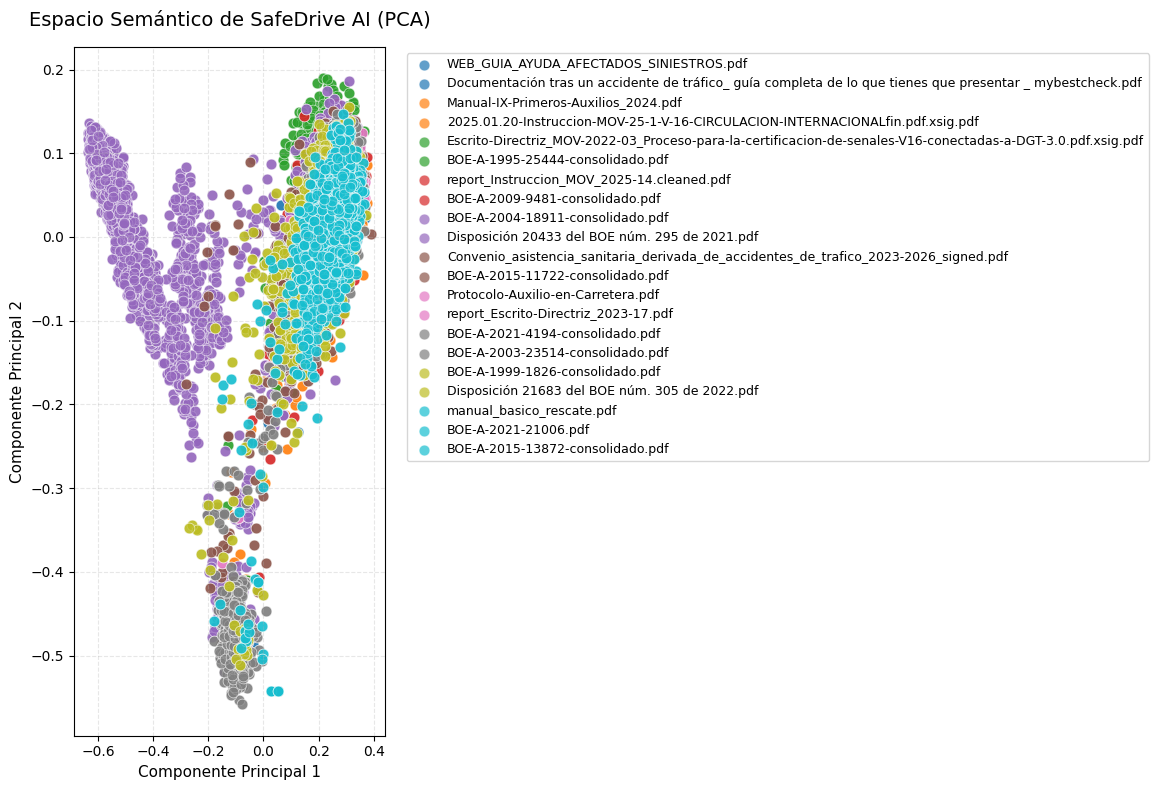

In [20]:
print("🎨 Extrayendo vectores y generando proyección PCA 2D...")

# 1. Extraemos todo el contenido de la colección para este paso y el siguiente
datos_coleccion = vectorstore.get(include=["embeddings", "metadatas", "documents"])
vectores = np.array(datos_coleccion["embeddings"])

# 2. Extraemos las fuentes para asignar colores
fuentes = [meta.get("source", "Desconocido") for meta in datos_coleccion["metadatas"]]
fuentes_unicas = list(set(fuentes))

# 3. Reducción dimensional PCA (De >700 dimensiones a 2)
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(vectores)

# 4. Renderizado del gráfico
plt.figure(figsize=(12, 8))
colores = plt.cm.get_cmap('tab10', len(fuentes_unicas))

for i, fuente in enumerate(fuentes_unicas):
    idx = [j for j, f in enumerate(fuentes) if f == fuente]
    plt.scatter(
        coords_2d[idx, 0], coords_2d[idx, 1], 
        alpha=0.7, label=fuente, color=colores(i),
        edgecolors='w', linewidth=0.5, s=60
    )

plt.title("Espacio Semántico de SafeDrive AI (PCA)", fontsize=14, pad=15)
plt.xlabel("Componente Principal 1", fontsize=11)
plt.ylabel("Componente Principal 2", fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

plt.show()

## 📊 Paso 10: Exportar a TensorFlow Embedding Projector
Genera los archivos `.tsv` para navegar el espacio tridimensional en la web oficial de TensorFlow.

In [21]:
print("📦 Exportando base de datos a formato TSV...")

# Exportar embeddings.tsv
with open("embeddings.tsv", "w", newline="", encoding="utf-8") as f_vec:
    writer = csv.writer(f_vec, delimiter="\t")
    writer.writerows(datos_coleccion["embeddings"])

# Exportar metadata.tsv
with open("metadata.tsv", "w", newline="", encoding="utf-8") as f_meta:
    writer = csv.writer(f_meta, delimiter="\t")
    writer.writerow(["Fuente", "Pagina", "Texto_Muestra"]) 
    
    for meta, doc in zip(datos_coleccion["metadatas"], datos_coleccion["documents"]):
        texto_limpio = doc.replace("\n", " ").replace("\t", " ")[:150] + "..."
        writer.writerow([meta.get("source", "Desconocido"), meta.get("pagina", 0), texto_limpio])

print("✅ ¡Archivos 'embeddings.tsv' y 'metadata.tsv' generados con éxito!")
print("👉 Sube ambos archivos a: https://projector.tensorflow.org/")

📦 Exportando base de datos a formato TSV...
✅ ¡Archivos 'embeddings.tsv' y 'metadata.tsv' generados con éxito!
👉 Sube ambos archivos a: https://projector.tensorflow.org/
